In [1]:
!pip install BerTopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 104.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 89.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [6]:
!pip install pandarallel

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 10.6 MB/s eta 0:00:00
  Created wheel for pandarallel: filename=pandarallel-1.6.5-py3-none-any.whl size=16674 sha256=5b3e3fe52ae535b14ce2b8600b84b2b0d9bc44af29c37bd6fb141a002945414b
  Stored in directory: /root/.cache/pip/wheels/b9/c6/5a/829298789e94348b81af52ab42c19d49da007306bbcc983827
Successfully built pandarallel


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.chdir('/content/drive/MyDrive/PAN_LLM_Data_Generation_Normal_Prompt_Gemini/Generated_Datasets/1_Raw_Dataset')
print(os.getcwd())

/content/drive/.shortcut-targets-by-id/1y1KHKUIfZ8qZ9Gfub7BK_4_J0EVsATeX/PAN_LLM_Data_Generation_Normal_Prompt_Gemini/Generated_Datasets/1_Raw_Dataset


# Program

In [48]:
import pandas as pd
import numpy as np
import spacy
import re
import time
import cupy as cp
from tqdm.auto import tqdm
from pandarallel import pandarallel
from joblib import Parallel, delayed
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Load SpaCy model with GPU acceleration
spacy.require_gpu()
nlp = spacy.load("en_core_web_sm")
pandarallel.initialize(progress_bar=True)
tqdm.pandas()

# Step 1: Load Data
def load_data():
    print("Loading data from CSV files...")
    df = pd.concat([
        pd.read_csv('train.csv'),
        pd.read_csv('valid.csv'),
        pd.read_csv('test.csv')
    ])
    print(f"Data loaded successfully. Total records: {len(df)}")
    return df["text"]

# Step 2: Preprocess Text
def preprocess_text(texts):
    print("Preprocessing text using parallel processing...")
    start_time = time.time()

    def clean_text(text):
        text = re.sub(r'[^a-zA-Z\s]', '', str(text))
        text = text.lower().strip()
        return text

    def lemmatize_text(text):
        doc = nlp(text)
        return ' '.join([token.lemma_ for token in doc if not token.is_stop])

    cleaned_texts = pd.Series(texts).parallel_apply(clean_text)
    lemmatized_texts = cleaned_texts.progress_apply(lemmatize_text)

    elapsed_time = time.time() - start_time
    print(f"Text preprocessing complete. Time taken: {elapsed_time:.2f} seconds")
    return lemmatized_texts.tolist()

# Step 3: Apply BERTopic
def apply_bertopic(texts):
    print("Applying BERTopic with GPU...")
    start_time = time.time()
    model = BERTopic(embedding_model=SentenceTransformer("all-MiniLM-L6-v2", device="cuda"))
    topics, _ = model.fit_transform(texts)
    elapsed_time = time.time() - start_time
    print(f"BERTopic modeling complete. Time taken: {elapsed_time:.2f} seconds")
    return model, topics, model.get_topic_info()

def get_most_frequent_bertopic_topics(topic_info, top_n=10):
    print("\nMost Frequent BERTopic Topics:")
    frequent_topics = topic_info.sort_values(by="Count", ascending=False).head(top_n)
    print(frequent_topics[["Topic", "Name", "Count"]])
    return frequent_topics

def visualize_bertopic(model):
    print("Visualizing BERTopic results...")
    model.visualize_barchart().show()
    model.visualize_heatmap().show()
    model.visualize_term_rank().show()

def save_bertopic_visualizations(model):
    print("Saving BERTopic visualizations as HTML files...")

    model.visualize_barchart().write_html("/content/drive/MyDrive/PAN_LLM_Data_Generation_Normal_Prompt_Gemini/0_Topic Modelling/Results/bertopic_barchart.html")
    model.visualize_heatmap().write_html("/content/drive/MyDrive/PAN_LLM_Data_Generation_Normal_Prompt_Gemini/0_Topic Modelling/Results/bertopic_heatmap.html")
    model.visualize_term_rank().write_html("/content/drive/MyDrive/PAN_LLM_Data_Generation_Normal_Prompt_Gemini/0_Topic Modelling/Results/bertopic_term_rank.html")

    print("BERTopic visualizations saved.")

def store_bertopic_results(topics, topic_info):
    topic_info.to_csv('/content/drive/MyDrive/PAN_LLM_Data_Generation_Normal_Prompt_Gemini/0_Topic Modelling/Results/bertopic_results.csv', index=False)

# Step 4: Apply LDA
def apply_lda(texts, num_topics=10):
    print("Applying LDA with GPU acceleration...")
    start_time = time.time()
    vectorizer = CountVectorizer()
    doc_term_matrix = vectorizer.fit_transform(texts)
    lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
    lda_topics = lda_model.fit_transform(doc_term_matrix)
    feature_names = vectorizer.get_feature_names_out()
    topic_names = {i: ', '.join([feature_names[idx] for idx in topic.argsort()[:-11:-1]]) for i, topic in enumerate(lda_model.components_)}
    elapsed_time = time.time() - start_time
    print(f"LDA topic modeling complete. Time taken: {elapsed_time:.2f} seconds")
    return lda_model, vectorizer, lda_topics, topic_names

def get_most_frequent_lda_topics(lda_topics, topic_names, top_n=10):
    print("\nMost Frequent LDA Topics:")
    topic_counts = pd.Series(lda_topics.argmax(axis=1)).value_counts().head(top_n)
    topic_counts.index = topic_counts.index.map(topic_names)
    print(topic_counts)
    return topic_counts

# Visualization for LDA
def visualize_lda(lda_model, vectorizer, num_words=10):
    print("Visualizing LDA topics...")
    topics = {i: [vectorizer.get_feature_names_out()[idx] for idx in topic.argsort()[:-num_words - 1:-1]]
              for i, topic in enumerate(lda_model.components_)}

    for topic_num, words in topics.items():
        print(f"Topic {topic_num}: {', '.join(words)}")
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(words))
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"Topic {topic_num}")
        plt.show()

def save_lda_visualizations(lda_model, vectorizer, num_words=10):
    print("Saving LDA topic visualizations...")
    topics = {i: [vectorizer.get_feature_names_out()[idx] for idx in topic.argsort()[:-num_words - 1:-1]]
              for i, topic in enumerate(lda_model.components_)}

    for topic_num, words in topics.items():
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(words))
        wordcloud.to_file(f"/content/drive/MyDrive/PAN_LLM_Data_Generation_Normal_Prompt_Gemini/0_Topic Modelling/Results/lda_topic_{topic_num}.png")

    print("LDA visualizations saved.")

def store_lda_results(lda_topics, topic_names):
    df = pd.DataFrame(lda_topics)
    df["Topic Name"] = df.idxmax(axis=1).map(topic_names)
    df.to_csv('/content/drive/MyDrive/PAN_LLM_Data_Generation_Normal_Prompt_Gemini/0_Topic Modelling/Results/lda_results.csv', index=False)

# Step 5: Apply NMF
def apply_nmf(texts, num_topics=10):
    print("Applying NMF with GPU acceleration...")
    start_time = time.time()
    vectorizer = TfidfVectorizer()
    doc_term_matrix = vectorizer.fit_transform(texts)
    nmf_model = NMF(n_components=num_topics, random_state=42)
    nmf_topics = nmf_model.fit_transform(doc_term_matrix)
    feature_names = vectorizer.get_feature_names_out()
    topic_names = {i: ', '.join([feature_names[idx] for idx in topic.argsort()[:-11:-1]]) for i, topic in enumerate(nmf_model.components_)}
    elapsed_time = time.time() - start_time
    print(f"NMF topic modeling complete. Time taken: {elapsed_time:.2f} seconds")
    return nmf_model, vectorizer, nmf_topics, topic_names

def get_most_frequent_nmf_topics(nmf_topics, topic_names, top_n=10):
    print("\nMost Frequent NMF Topics:")
    topic_counts = pd.Series(nmf_topics.argmax(axis=1)).value_counts().head(top_n)
    topic_counts.index = topic_counts.index.map(topic_names)
    print(topic_counts)
    return topic_counts

# Visualization for NMF
def visualize_nmf(nmf_model, vectorizer, num_words=10):
    print("Visualizing NMF topics...")
    topics = {i: [vectorizer.get_feature_names_out()[idx] for idx in topic.argsort()[:-num_words - 1:-1]]
              for i, topic in enumerate(nmf_model.components_)}

    for topic_num, words in topics.items():
        print(f"Topic {topic_num}: {', '.join(words)}")
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(words))
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"Topic {topic_num}")
        plt.show()

def save_nmf_visualizations(nmf_model, vectorizer, num_words=10):
    print("Saving NMF topic visualizations...")
    topics = {i: [vectorizer.get_feature_names_out()[idx] for idx in topic.argsort()[:-num_words - 1:-1]]
              for i, topic in enumerate(nmf_model.components_)}

    for topic_num, words in topics.items():
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(words))
        wordcloud.to_file(f"/content/drive/MyDrive/PAN_LLM_Data_Generation_Normal_Prompt_Gemini/0_Topic Modelling/Results/nmf_topic_{topic_num}.png")

    print("NMF visualizations saved.")

def store_nmf_results(nmf_topics, topic_names):
    df = pd.DataFrame(nmf_topics)
    df["Topic Name"] = df.idxmax(axis=1).map(topic_names)
    df.to_csv('/content/drive/MyDrive/PAN_LLM_Data_Generation_Normal_Prompt_Gemini/0_Topic Modelling/Results/nmf_results.csv', index=False)


INFO: Pandarallel will run on 1 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


# Model Training and Visualization

In [18]:
print("Starting topic modeling pipeline...")
all_texts = load_data().tolist()
cleaned_texts = preprocess_text(all_texts)

Starting topic modeling pipeline...
Loading data from CSV files...
Data loaded successfully. Total records: 16000
Preprocessing text using parallel processing...


  0%|          | 0/16000 [00:00<?, ?it/s]

Text preprocessing complete. Time taken: 1030.21 seconds


In [27]:
print("Applying BERTopic...")
bert_model, bert_topics, bert_topic_info = apply_bertopic(cleaned_texts)
visualize_bertopic(bert_model)

Applying BERTopic...
Applying BERTopic with GPU...
BERTopic modeling complete. Time taken: 59.69 seconds
Visualizing BERTopic results...


Applying LDA...
Applying LDA with GPU acceleration...
LDA topic modeling complete. Time taken: 105.88 seconds
Visualizing LDA topics...
Topic 0: drive, file, disk, partition, not, datum, boot, system, use, window


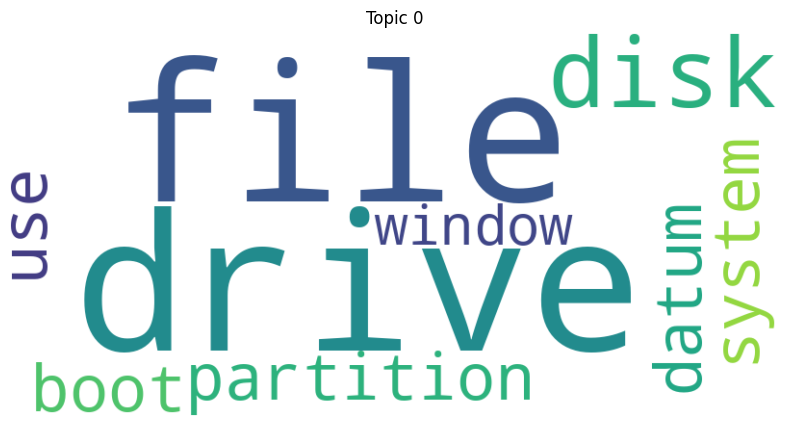

Topic 1: window, run, not, system, work, machine, install, use, server, instal


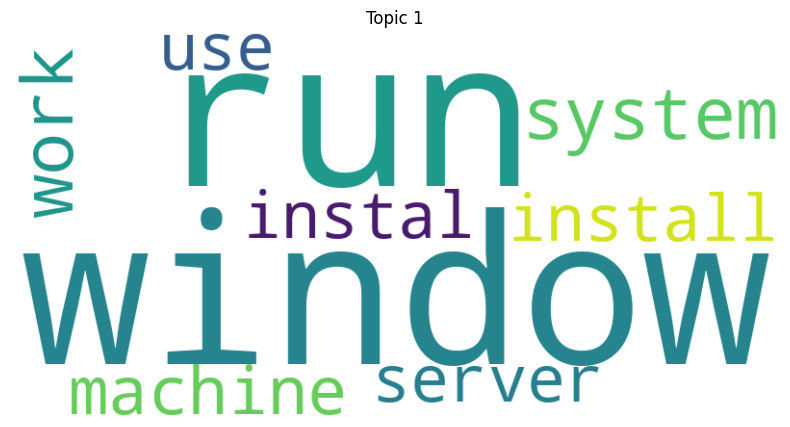

Topic 2: network, router, ip, server, connection, address, port, connect, not, use


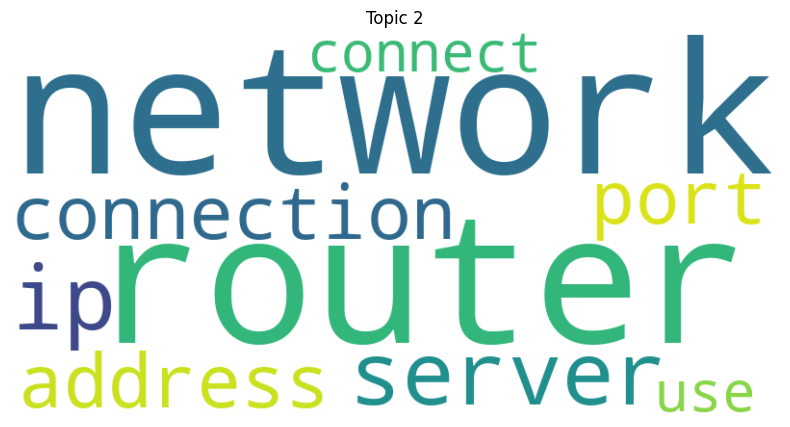

Topic 3: file, user, not, database, log, server, table, need, change, use


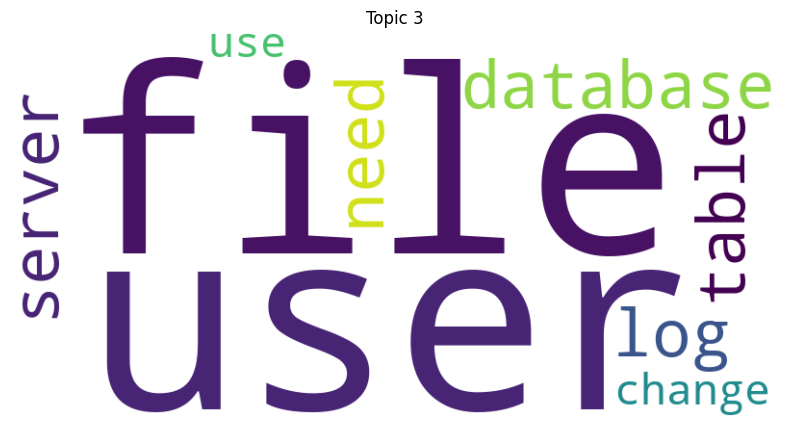

Topic 4: server, not, need, raid, run, use, backup, host, instance, datum


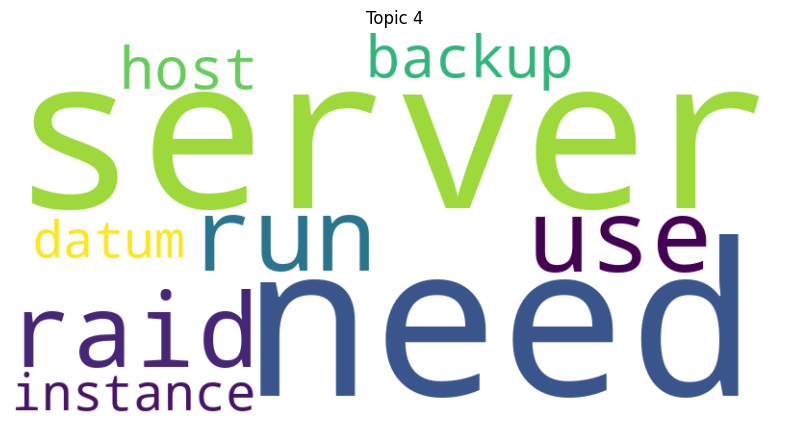

Topic 5: game, not, code, need, like, use, time, value, datum, object


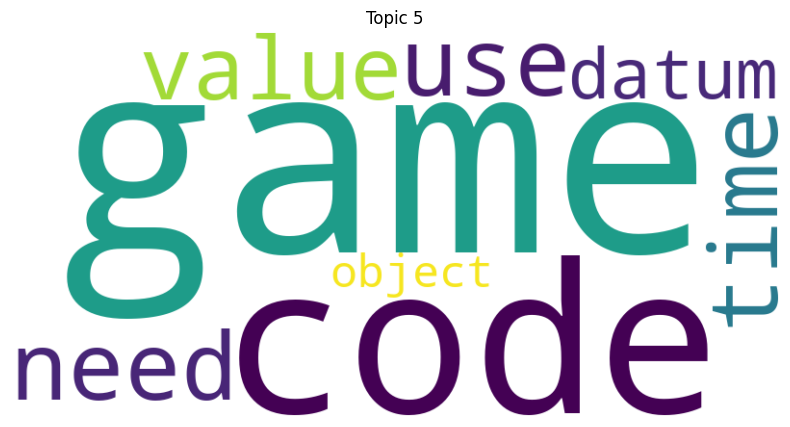

Topic 6: use, file, not, command, run, code, script, like, want, work


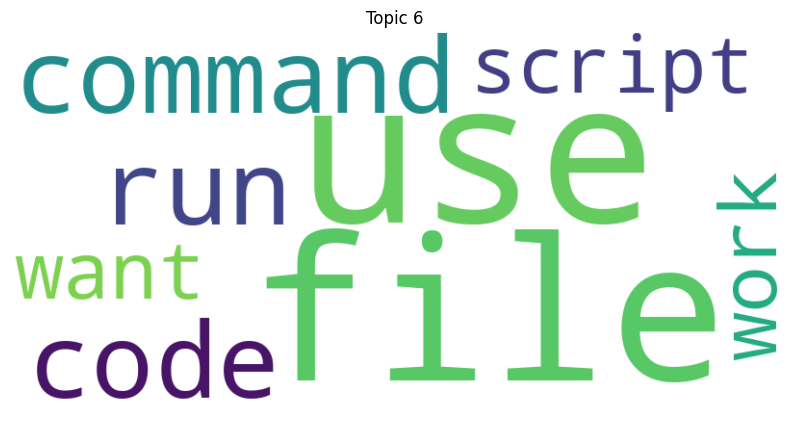

Topic 7: server, dns, domain, address, ip, host, site, not, request, email


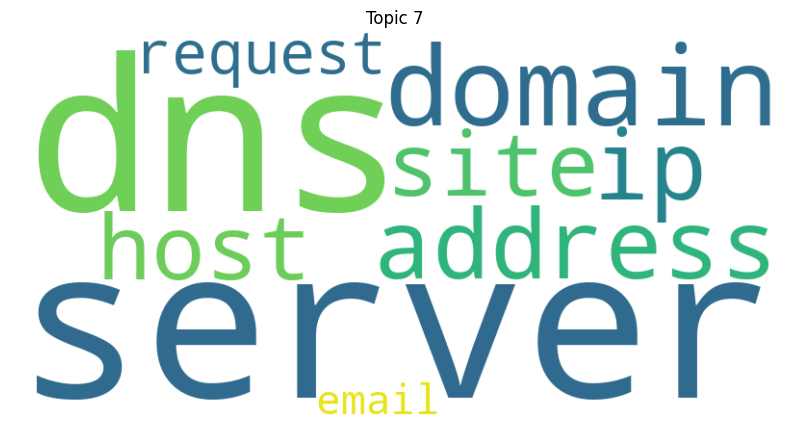

Topic 8: power, not, cpu, card, device, run, work, cable, use, laptop


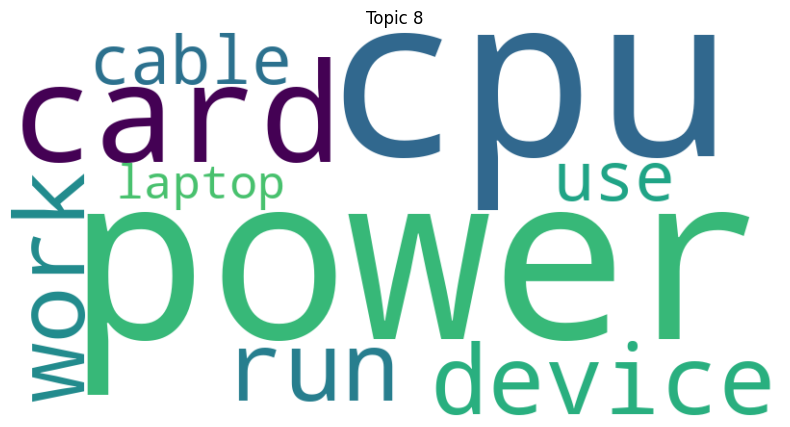

Topic 9: not, use, work, click, like, problem, file, want, change, find


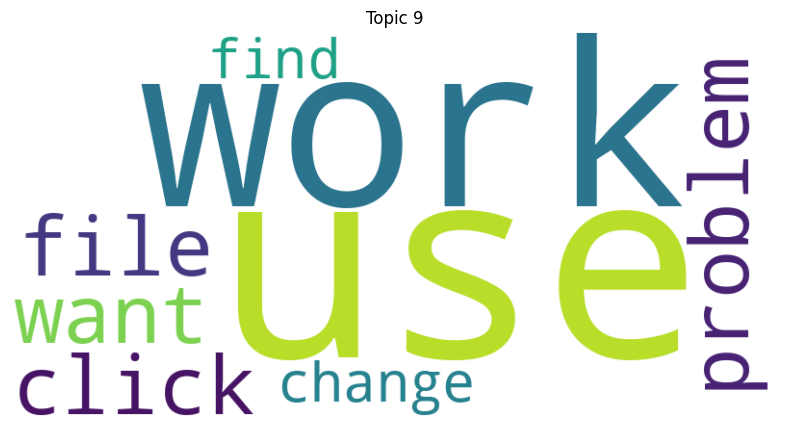

In [29]:
print("Applying LDA...")
lda_model, lda_vectorizer, lda_topics, lda_topic_names = apply_lda(cleaned_texts)
visualize_lda(lda_model, lda_vectorizer)

Applying NMF...
Applying NMF with GPU acceleration...
NMF topic modeling complete. Time taken: 8.44 seconds
Visualizing NMF topics...
Topic 0: window, install, boot, driver, update, instal, version, computer, work, machine


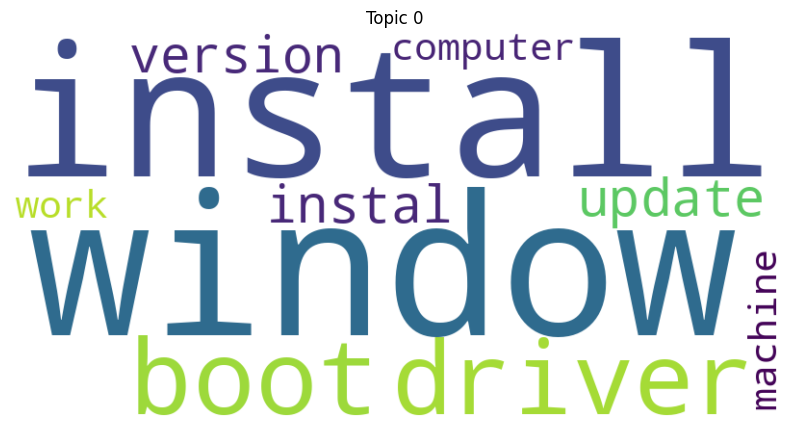

Topic 1: router, ip, network, address, port, connect, switch, device, connection, route


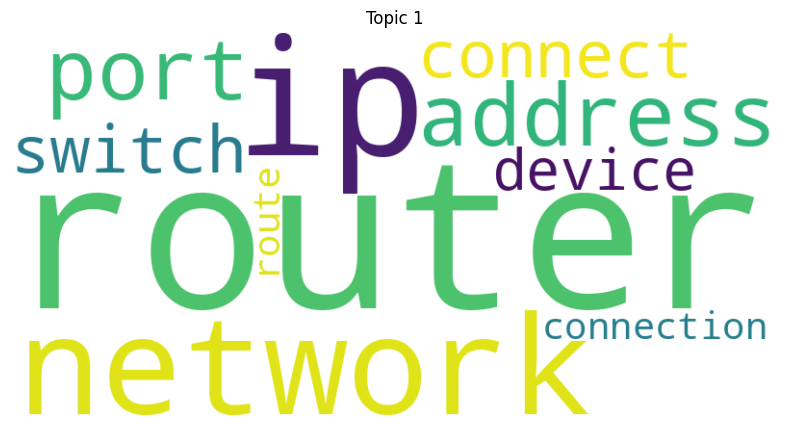

Topic 2: drive, disk, raid, partition, datum, hard, backup, boot, usb, ssd


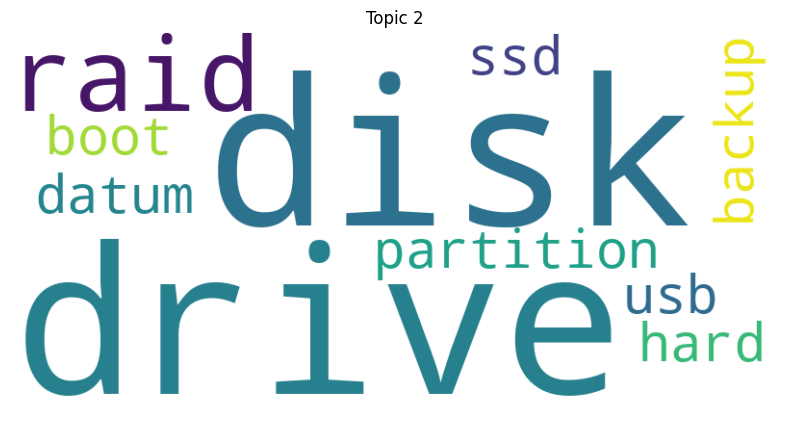

Topic 3: code, game, function, class, not, object, use, value, method, like


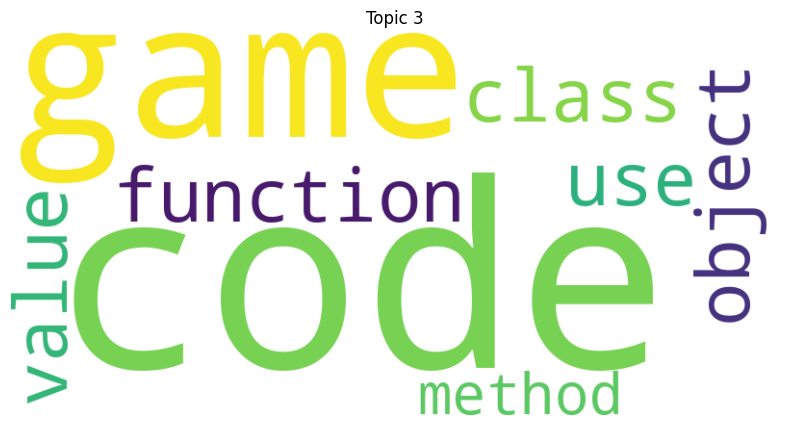

Topic 4: server, client, sql, run, web, host, connection, database, machine, port


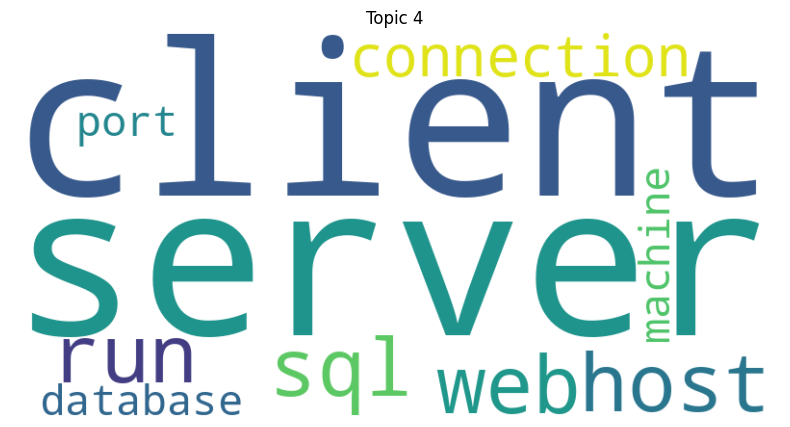

Topic 5: file, folder, directory, copy, backup, command, script, delete, open, rsync


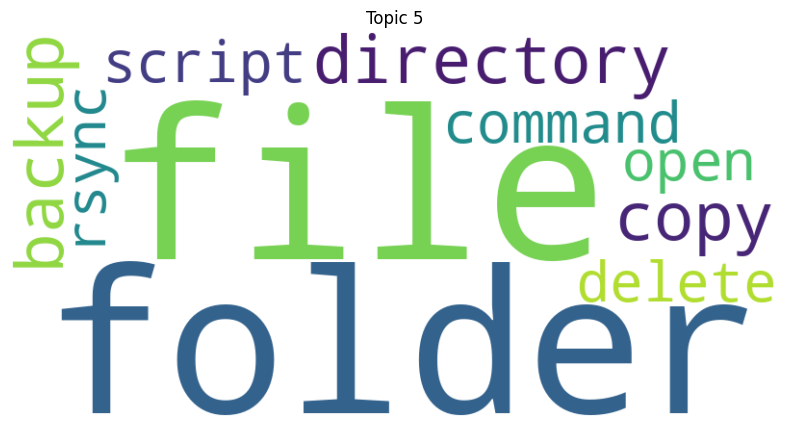

Topic 6: dns, domain, ip, record, address, server, email, mail, host, zone


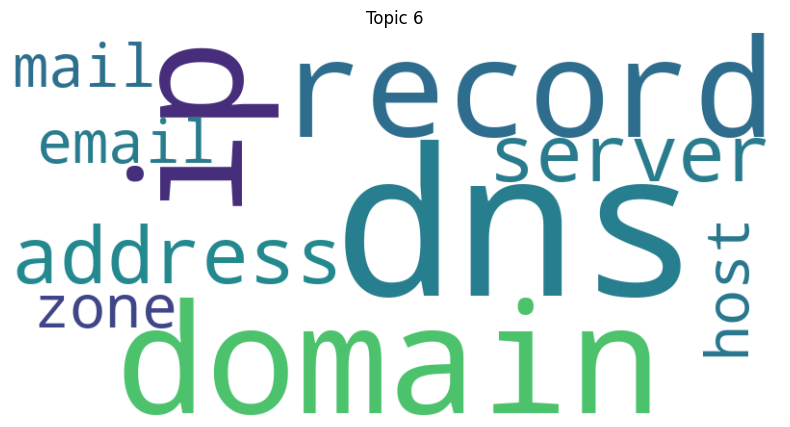

Topic 7: table, database, query, index, column, row, datum, sql, key, mysql


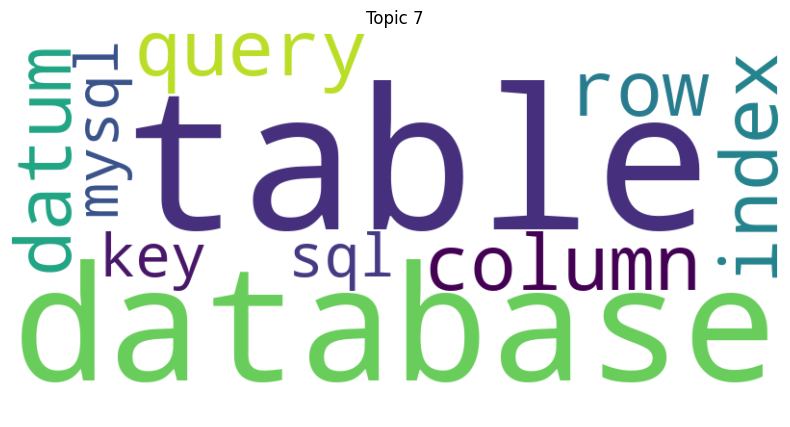

Topic 8: user, password, account, group, access, permission, log, domain, policy, login


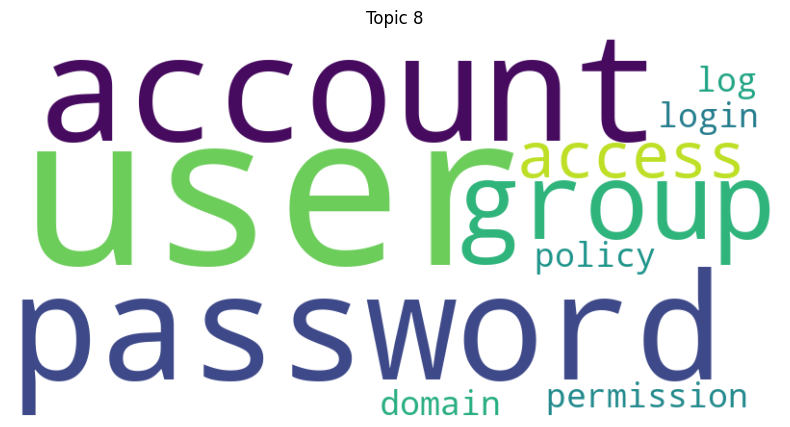

Topic 9: memory, power, ram, cpu, gb, card, run, system, not, bit


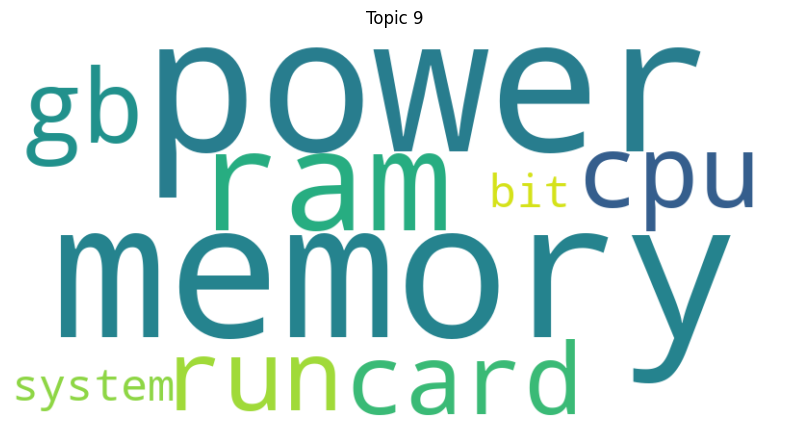

In [30]:
print("Applying NMF...")
nmf_model, nmf_vectorizer, nmf_topics, nmf_topic_names = apply_nmf(cleaned_texts)
visualize_nmf(nmf_model, nmf_vectorizer)

# Save Results

In [35]:
store_bertopic_results(bert_topics, bert_topic_info)

In [36]:
store_lda_results(lda_topics, lda_topic_names)

In [37]:
store_nmf_results(nmf_topics, nmf_topic_names)

# Frequently Occuring Topics

In [49]:
top_bertopic_topics = get_most_frequent_bertopic_topics(bert_topic_info)


Most Frequent BERTopic Topics:
   Topic                            Name  Count
0     -1          -1_file_not_server_run   6321
1      0   0_email_mail_exchange_outlook    547
2      1    1_code_function_class_method    463
3      2        2_dns_domain_record_zone    366
4      3  3_model_feature_training_train    346
5      4  4_shader_texture_render_vertex    201
6      5         5_address_ip_router_nat    186
7      6     6_excel_cell_column_formula    186
8      7  7_update_wsus_office_installer    168
9      8      8_vpn_openvpn_route_tunnel    165


In [50]:
top_lda_topics = get_most_frequent_lda_topics(lda_topics, lda_topic_names)


Most Frequent LDA Topics:
file, user, not, database, log, server, table, need, change, use             2520
game, not, code, need, like, use, time, value, datum, object                 2362
network, router, ip, server, connection, address, port, connect, not, use    2069
window, run, not, system, work, machine, install, use, server, instal        2017
drive, file, disk, partition, not, datum, boot, system, use, window          1391
power, not, cpu, card, device, run, work, cable, use, laptop                 1231
not, use, work, click, like, problem, file, want, change, find               1228
server, dns, domain, address, ip, host, site, not, request, email            1187
server, not, need, raid, run, use, backup, host, instance, datum             1174
use, file, not, command, run, code, script, like, want, work                  821
Name: count, dtype: int64


In [51]:
top_nmf_topics = get_most_frequent_nmf_topics(nmf_topics, nmf_topic_names)



Most Frequent NMF Topics:
code, game, function, class, not, object, use, value, method, like                 3710
server, client, sql, run, web, host, connection, database, machine, port           1774
memory, power, ram, cpu, gb, card, run, system, not, bit                           1750
router, ip, network, address, port, connect, switch, device, connection, route     1698
file, folder, directory, copy, backup, command, script, delete, open, rsync        1541
user, password, account, group, access, permission, log, domain, policy, login     1459
window, install, boot, driver, update, instal, version, computer, work, machine    1245
drive, disk, raid, partition, datum, hard, backup, boot, usb, ssd                  1048
table, database, query, index, column, row, datum, sql, key, mysql                  987
dns, domain, ip, record, address, server, email, mail, host, zone                   788
Name: count, dtype: int64


# Save HTML and PNG of Results

In [45]:
save_bertopic_visualizations(bert_model)

Saving BERTopic visualizations as HTML files...
BERTopic visualizations saved.


In [46]:
save_lda_visualizations(lda_model, lda_vectorizer)

Saving LDA topic visualizations...
LDA visualizations saved.


In [47]:
save_nmf_visualizations(nmf_model, nmf_vectorizer)

Saving NMF topic visualizations...
NMF visualizations saved.
